In [34]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels openpyxl


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python3.13 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 01 - Exploración y Limpieza de Datos

**Proyecto:** Factores asociados al tiempo en situación de calle en Bogotá  
**Fuente:** VIII Censo de Ciudadanos Habitantes de Calle (2024) - SDIS/SDP  
**Enlace:** https://www.integracionsocial.gov.co/index.php/noticias/especiales/7107-censo-habitantes-de-calle-en-bogota-2024

Este notebook:
1. Carga el CSV anonimizado del censo.
2. Explora su estructura.
3. Construye la variable objetivo `tiempo_en_calle_meses`.
4. Limpia y guarda el dataset procesado en `data/processed/`.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

RUTA_RAW = '../data/raw/base_datos_anonimizada_censo_habitantes_calle.csv'

# Cargar el archivo (separador ; y encoding latin-1)
df = pd.read_csv(
    RUTA_RAW,
    sep=';',
    encoding='latin-1',
    quotechar='"',
    low_memory=False
)

print(f"✅ Dataset cargado")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

✅ Dataset cargado
Filas: 10478
Columnas: 152


## 1. Exploración inicial

In [36]:
# primeras filas del DataFrame
df.head()

,globalid,LOCALIDAD,COD_LOCALIDAD,UBIC,CTL1,P5,P6,P7,P7S1A,P7S1B,P9,P10,P11,P11S3,P12,no_sabe_edad_fecha,P13,P14S1,P14S2,P14S3,P14S4,P14S5,P14S6,P14S7,P14S8,P15,P16,P16S1,P17,P17_2,P17_3,P18S1,P18S2,P19,P20,P21,P22S1,P22S2,P22S3,P22S4,P22S5,P22S6,P22S7,P23S1,P23S2,P23S3,P23S4,P23S5,P23S6,P23S7,P23S8,P23S9,P23S10,visita_municipio,visita_pais,ninguna_ciudad_f24,P25S1,P25S2,P25S3,P25S4,P25S5,P26,P27,P28,P28_1S1,P28_1S2,P28_1S3,P28_1S4,P28_1S5,P28_1S6,P28_1S7,P28_1S8,P28_1S9,P28_1S10,P28_1S11,P28_2,P29S1,P29S1A1,P29S2,P29S2A1,P29S3,P29S3A1,P29S4,P29S4A1,P29S5,P29S5A1,P30S1,P30S1A1,P30S2,P30S2A1,P30S3,P30S3A1,P30S4,P30S4A1,P30S5,P30S5A1,P30S6,P30S6A1,P30S7,P30S7A1,P30S8,P30S8A1,P30S9,P30S9A1,P30_1,P30_2,P31,P31S1,P32,P33S1,P33S2,P33S3,P33S4,P33S5,P33S6,P33S7,P33S8,P33S9,P34,P35S1,P35S2,P35S3,P35S4,P35S5,P36,P37S1,P37S2,P37S3,P37S4,P37S5,P37S6,P37S7,P37S8,P37S9,P37S10,P37_1,P38,P38_1,P39,P39_1,P39_2,P39_3,P40,P40S1A,P40S1B,P40S2,P41,P42,P43,P44,P45,RES_FIN
0,{FE170795-7E95-4A66-876A-B14344D9BD9E},Santa Fe,3.0,1,2,8.0,NaN,1.0,Santa Fe,3.0,3.0,2.0,1.0,NaN,60,0.0,6.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,3.0,1.0,8.0,5.0,6.0,30,9.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,NaN,2.0,2.0,2.0,1.0,2.0,9.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,2.0,NaN,1.0,1.0,1.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,1.0,30.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,3.0,NaN,1.0,1.0,NaN,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,10.0,2.0,5.0,2,Vender,NaN,NaN,2.0,NaN,NaN,NaN,2.0,1.0,NaN,NaN,NaN,1
1,{EA923F84-50D0-4177-A74D-8417472FB8D2},Santa Fe,3.0,1,2,8.0,NaN,1.0,Santa Fe,3.0,12.0,1.0,2.0,NaN,40,0.0,6.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,3.0,3.0,6.0,11.0,NaN,20,9.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NoVisitadoNungunaCiudad,2.0,2.0,2.0,2.0,2.0,9.0,4.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,11.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,25.0,2.0,NaN,1.0,25.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,NaN,2.0,NaN,NaN,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0,1.0,5.0,2,Vender,NaN,NaN,2.0,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,1
2,{8C698641-E2AB-48C3-AC5A-AE3034A8A7D8},Santa Fe,3.0,1,2,8.0,NaN,1.0,Santa Fe,3.0,3.0,1.0,1.0,NaN,41,0.0,6.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,3.0,2.0,10.0,NaN,NaN,2,9.0,1.0,8.0,5.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NoVisitadoNungunaCiudad,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,20.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,1.0,1.0,1.0,NaN,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,2.0,5.0,"8,9",Construir,Reparar,NaN,1.0,8.0,10.0,3.0,1.0,2.0,NaN,NaN,NaN,1
3,{0DE6EAEB-5CCE-4F51-BD8F-EC0625AB2482},Santa Fe,3.0,1,2,8.0,NaN,1.0,Santa Fe,3.0,3.0,1.0,1.0,NaN,35,0.0,6.0,4.0,4.0,4.0,3.0,3.0,3.0,4.0,2.0,1.0,6.0,999.0,5.0,3.0,11.0,0,8.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,NaN,2.0,2.0,2.0,2.0,2.0,9.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,6.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,3.0,NaN,1.0,1.0,NaN,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,5.0,8,Construir,NaN,NaN,1.0,30.0,0.0,3.0,1.0,2.0,NaN,NaN,NaN,1
4,{4DE82932-7427-4EDB-99DE-C1D5A4A1E5D8},Santa Fe,3.0,1,2,8.0,NaN,1.0,Santa Fe,3.0,11.0,1.0,3.0,1.0,22,0.0,6.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,5.0,11.0,6.0,5.0,11.0,0,8.0,1.0,11.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,NaN,2.0,2.0,2.0,2.0,2.0,9.0,4.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,N

In [37]:
# Resumen de tipos de datos
print("--- Conteo de tipos de datos ---")
print(df.dtypes.value_counts())

print("\n--- Columnas numéricas ---")
print(df.select_dtypes(include='number').columns.tolist()[:30])

print("\n--- Columnas de texto ---")
print(df.select_dtypes(include='str').columns.tolist())

--- Conteo de tipos de datos ---
float64    138
str         11
int64        3
Name: count, dtype: int64

--- Columnas numéricas ---
['COD_LOCALIDAD', 'UBIC', 'CTL1', 'P5', 'P6', 'P7', 'P7S1B', 'P9', 'P10', 'P11', 'P11S3', 'no_sabe_edad_fecha', 'P13', 'P14S1', 'P14S2', 'P14S3', 'P14S4', 'P14S5', 'P14S6', 'P14S7', 'P14S8', 'P15', 'P16', 'P16S1', 'P17', 'P17_2', 'P17_3', 'P18S2', 'P19', 'P20']

--- Columnas de texto ---
['globalid', 'LOCALIDAD', 'P7S1A', 'P12', 'P18S1', 'ninguna_ciudad_f24', 'P39', 'P39_1', 'P39_2', 'P39_3', 'P44']


In [38]:
# Lista completa de columnas
print("--- Todas las columnas ---")
for i, col in enumerate(df.columns, 1):
    print(f"{i:3d}. {col}")

--- Todas las columnas ---
  1. globalid
  2. LOCALIDAD
  3. COD_LOCALIDAD
  4. UBIC
  5. CTL1
  6. P5
  7. P6
  8. P7
  9. P7S1A
 10. P7S1B
 11. P9
 12. P10
 13. P11
 14. P11S3
 15. P12
 16. no_sabe_edad_fecha
 17. P13
 18. P14S1
 19. P14S2
 20. P14S3
 21. P14S4
 22. P14S5
 23. P14S6
 24. P14S7
 25. P14S8
 26. P15
 27. P16
 28. P16S1
 29. P17
 30. P17_2
 31. P17_3
 32. P18S1
 33. P18S2
 34. P19
 35. P20
 36. P21
 37. P22S1
 38. P22S2
 39. P22S3
 40. P22S4
 41. P22S5
 42. P22S6
 43. P22S7
 44. P23S1
 45. P23S2
 46. P23S3
 47. P23S4
 48. P23S5
 49. P23S6
 50. P23S7
 51. P23S8
 52. P23S9
 53. P23S10
 54. visita_municipio
 55. visita_pais
 56. ninguna_ciudad_f24
 57. P25S1
 58. P25S2
 59. P25S3
 60. P25S4
 61. P25S5
 62. P26
 63. P27
 64. P28
 65. P28_1S1
 66. P28_1S2
 67. P28_1S3
 68. P28_1S4
 69. P28_1S5
 70. P28_1S6
 71. P28_1S7
 72. P28_1S8
 73. P28_1S9
 74. P28_1S10
 75. P28_1S11
 76. P28_2
 77. P29S1
 78. P29S1A1
 79. P29S2
 80. P29S2A1
 81. P29S3
 82. P29S3A1
 83. P29S4
 84. P29S4A

## 2. Construcción de la variable objetivo

La variable objetivo es **`tiempo_en_calle_meses`**, que se construye a partir de:

- `P18S1`: años viviendo en calle (string, puede ser "60 años o más"). #
- `P18S2`: meses viviendo en calle (numérico).

Fórmula: `Y = años * 12 + meses`

In [45]:
# --- Limpieza de columnas con strings sucios ---

def parsear_a_numero(valor):
    if pd.isna(valor):
        return np.nan
    valor = str(valor).strip().lower()
    
    # Casos especiales
    if 'menos de' in valor:
        return 14  # Asumimos 14 como valor para "menos de 15"
    if 'años' in valor or 'anos' in valor or 'más' in valor:
        try:
            # Extraer el primer número que aparezca
            numero = ''.join(c for c in valor if c.isdigit() or c == '.' or c == '-')
            return float(numero)
        except:
            return np.nan
    try:
        return float(valor)
    except:
        return np.nan

# Paso 1: Crear un DataFrame temporal con todas las columnas nuevas
nuevas_cols = pd.DataFrame({
    'anios_calle': df['P18S1'].apply(parsear_a_numero),
    'meses_calle': pd.to_numeric(df['P18S2'], errors='coerce').fillna(0),
    'edad': df['P12'].apply(parsear_a_numero)
})

# Paso 2: Calcular la variable objetivo dentro del DataFrame temporal
nuevas_cols['tiempo_en_calle_meses'] = nuevas_cols['anios_calle'] * 12 + nuevas_cols['meses_calle']

# Paso 3: Unir (concatenar) las nuevas columnas al DataFrame original de una sola vez
df = pd.concat([df, nuevas_cols], axis=1)

print("✅ Variables construidas")
print("\n--- Estadísticas ---")
print(df[['edad', 'anios_calle', 'meses_calle', 'tiempo_en_calle_meses']].describe().round(2))

✅ Variables construidas

--- Estadísticas ---
          edad     edad  anios_calle  anios_calle  meses_calle  meses_calle  tiempo_en_calle_meses  tiempo_en_calle_meses
count  8759.00  8759.00      8649.00      8649.00     10478.00     10478.00                8649.00                8649.00
mean     40.95    40.95        12.65        12.65         1.52         1.52                 153.65                 153.65
std      13.27    13.27        11.86        11.86         2.90         2.90                 141.95                 141.95
min      18.00    18.00         0.00         0.00         0.00         0.00                   0.00                   0.00
25%      30.50    30.50         3.00         3.00         0.00         0.00                  36.00                  36.00
50%      39.00    39.00        10.00        10.00         0.00         0.00                 120.00                 120.00
75%      49.00    49.00        20.00        20.00         2.00         2.00                 240.00  

In [40]:
# ¿Cuántos valores nulos tenemos?
print("--- Valores nulos en variables clave ---")
print(df[['edad', 'tiempo_en_calle_meses']].isnull().sum())

# Ver registros con tiempo_en_calle = 0 o negativo
print(f"\nRegistros con tiempo = 0: {(df['tiempo_en_calle_meses'] == 0).sum()}")
print(f"Registros con tiempo < 0: {(df['tiempo_en_calle_meses'] < 0).sum()}")
print(f"Registros con tiempo > 600 meses (50 años): {(df['tiempo_en_calle_meses'] > 600).sum()}")

--- Valores nulos en variables clave ---
edad                     1719
tiempo_en_calle_meses    1829
dtype: int64

Registros con tiempo = 0: 71
Registros con tiempo < 0: 0
Registros con tiempo > 600 meses (50 años): 65


## 3. Limpieza final

Filtramos los registros para dejar solo aquellos que:
- Tengan edad y tiempo en calle válidos.
- Tengan tiempo en calle > 0.
- Hayan sido recolectados por **entrevista** (CTL1 = 2), no por observación.

In [41]:
print(f"Registros iniciales: {len(df)}")

# Filtro 1: solo entrevistas directas (no observación)
df_clean = df[df['CTL1'] == 2].copy()
print(f"Después de filtrar CTL1 == 2: {len(df_clean)}")

# Filtro 2: edad y tiempo válidos
df_clean = df_clean.dropna(subset=['edad', 'tiempo_en_calle_meses'])
print(f"Después de eliminar nulos: {len(df_clean)}")

# Filtro 3: tiempo en calle > 0
df_clean = df_clean[df_clean['tiempo_en_calle_meses'] > 0]
print(f"Después de tiempo > 0: {len(df_clean)}")

# Filtro 4: edad razonable (18 a 100 años)
df_clean = df_clean[(df_clean['edad'] >= 18) & (df_clean['edad'] <= 100)]
print(f"Después de filtrar edad 18-100: {len(df_clean)}")

# Filtro 5: tiempo en calle máximo razonable (60 años * 12 = 720)
df_clean = df_clean[df_clean['tiempo_en_calle_meses'] <= 720]
print(f"Después de tiempo <= 720: {len(df_clean)}")

# === NUEVO PASO: ELIMINAR EL RESTO DE COLUMNAS ===
# Nos quedamos estrictamente con las variables del modelo numérico
df_clean = df_clean[['edad', 'tiempo_en_calle_meses']]
print(f"Columnas finales retenidas: {df_clean.columns.tolist()}")

Registros iniciales: 10478
Después de filtrar CTL1 == 2: 8795
Después de eliminar nulos: 8648
Después de tiempo > 0: 8578
Después de filtrar edad 18-100: 8578
Después de tiempo <= 720: 8569
Columnas finales retenidas: ['edad', 'tiempo_en_calle_meses']


In [42]:
print("--- Estadísticas finales de la variable objetivo ---")
print(df_clean['tiempo_en_calle_meses'].describe().round(2))

print("\n--- Estadísticas de la edad ---")
print(df_clean['edad'].describe().round(2))

--- Estadísticas finales de la variable objetivo ---
count    8569.00
mean      154.32
std       140.71
min         1.00
25%        36.00
50%       120.00
75%       240.00
max       720.00
Name: tiempo_en_calle_meses, dtype: float64

--- Estadísticas de la edad ---
count    8569.00
mean       40.97
std        13.23
min        18.00
25%        31.00
50%        39.00
75%        49.00
max        75.00
Name: edad, dtype: float64


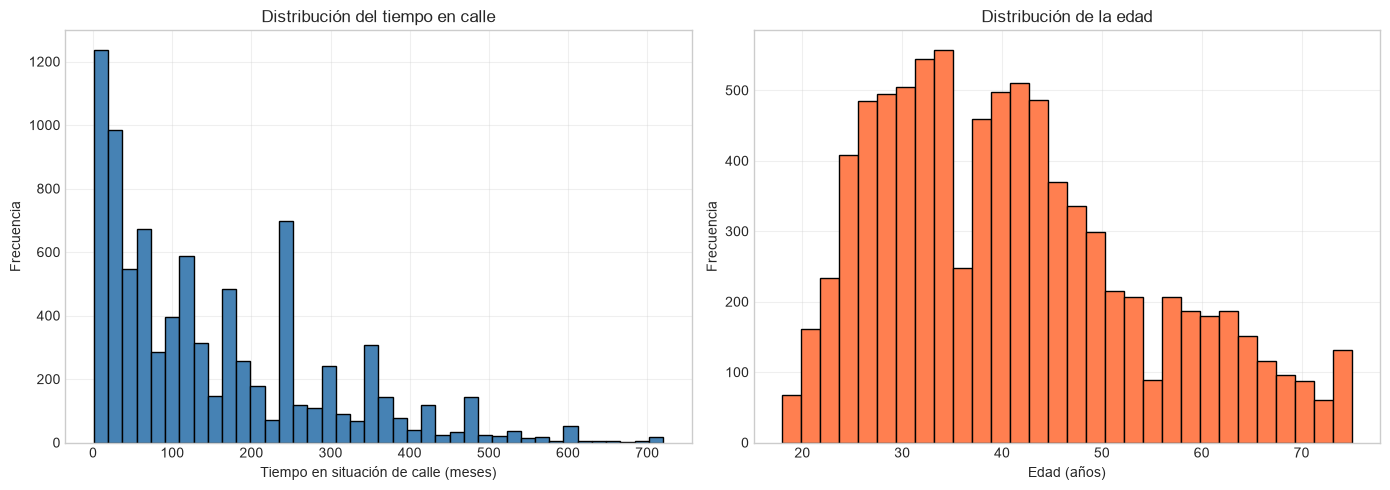

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de Y
axes[0].hist(df_clean['tiempo_en_calle_meses'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Tiempo en situación de calle (meses)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del tiempo en calle')
axes[0].grid(alpha=0.3)

# Histograma de edad
axes[1].hist(df_clean['edad'], bins=30, color='coral', edgecolor='black')
axes[1].set_xlabel('Edad (años)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de la edad')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figuras/01_distribuciones.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Guardar el dataset procesado

In [44]:
# Guardar dataset limpio 
ruta_procesado = '../data/processed/datos_limpios.csv'
os.makedirs('../data/processed/', exist_ok=True)
df_clean.to_csv(ruta_procesado, index=False, sep=';')

print(f"✅ Dataset guardado en: {ruta_procesado}")
print(f"Filas: {len(df_clean)}")
print(f"Columnas: {df_clean.shape[1]}") 

✅ Dataset guardado en: ../data/processed/datos_limpios.csv
Filas: 8569
Columnas: 2
